Iteration 0: Cost 33932779079.30065
Iteration 200: Cost 682029896.1065503
Iteration 400: Cost 73956263.6009807
Iteration 600: Cost 62191066.65405213
Iteration 800: Cost 61941813.9384085
Iteration 1000: Cost 61935729.907951154
Iteration 1200: Cost 61935553.05731302
Iteration 1400: Cost 61935547.03745624
Iteration 1600: Cost 61935546.809449494
Iteration 1800: Cost 61935546.80029012

Trained Theta:
 [[252262.90286318]
 [ 34177.55002889]
 [ 57042.67441128]
 [ 21185.65222518]
 [ 16591.88932238]
 [ 16180.35287257]
 [ 12244.93432922]
 [  7238.9437009 ]
 [  -331.14903263]]

R² Score: 0.9779036757325645


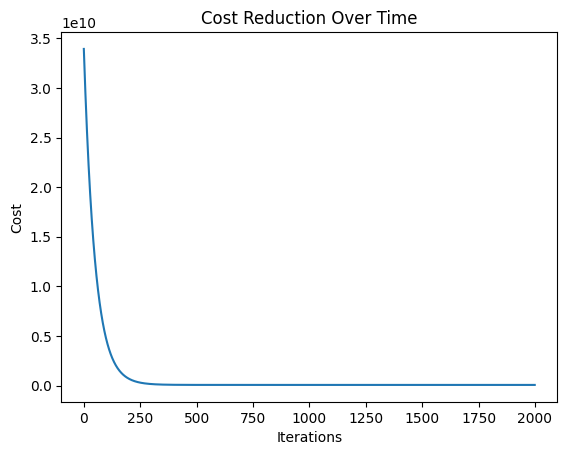

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Linear Regression From Scratch
# ==============================

class LinearRegressionScratch:
    def __init__(self, learning_rate, iterations):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.theta = None
        self.cost_history = []

    def compute_cost(self, X, y):
        m = len(y)
        y_pred = np.dot(X, self.theta)
        return (1 / (2 * m)) * np.sum((y_pred - y) ** 2)

    def fit(self, X, y):
        m = len(y)
        self.theta = np.zeros((X.shape[1], 1))
        self.cost_history = []
        y_pred_before = np.dot(X_b, self.theta)


        for i in range(self.iterations):
            y_pred = np.dot(X, self.theta)
            gradient = (1 / m) * np.dot(X.T, (y_pred - y))
            self.theta -= self.learning_rate * gradient

            cost = self.compute_cost(X, y)
            self.cost_history.append(cost)

            if i % 200 == 0:
                print(f"Iteration {i}: Cost {cost}")

        return self.theta, self.cost_history, y_pred_before

    def predict(self, X):
        return np.dot(X, self.theta)


# ==============================
# Load Data
# ==============================

data = pd.read_csv("house_prices_practice.csv")

# Removed 'Id'
feature_columns = [
    'OverallQual', 'GrLivArea', 'GarageCars',
    'TotalBsmtSF', 'YearBuilt',
    'FullBath', 'BedroomAbvGr', 'LotArea'
]
target_column = 'SalePrice'

X = data[feature_columns].values
y = data[target_column].values.reshape(-1, 1)

# ==============================
# Manual Feature Scaling
# ==============================

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

# Add bias (intercept term)
X_b = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]

# ==============================
# Train Model
# ==============================

learning_rate = 0.01
iterations = 2000

model = LinearRegressionScratch(learning_rate, iterations)
theta_trained, cost_history,y_pred_before = model.fit(X_b, y)

print("\nTrained Theta:\n", theta_trained)

# ==============================
# Predictions
# ==============================

y_pred = model.predict(X_b)

# ==============================
# R² Score
# ==============================

ss_total = np.sum((y - y.mean()) ** 2)
ss_residual = np.sum((y - y_pred) ** 2)
r2_score = 1 - (ss_residual / ss_total)

print("\nR² Score:", r2_score)

# ==============================
# Plot Cost Curve
# ==============================

plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction Over Time")
plt.show()

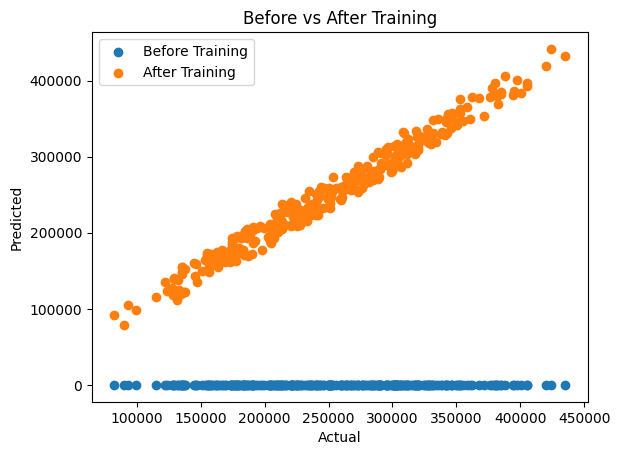

In [7]:
plt.scatter(y, y_pred_before, label="Before Training")
plt.scatter(y, y_pred, label="After Training")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.title("Before vs After Training")
plt.show()